## Does solar activity affect the market? 

This notebook investigates whether the certain astronomical feature (sunspot frequency) provides meaningful information for the behavior of the S&P 500 log returns. 

### TL;DR

Our analysis, based on graphical inspection and linear OLS-based regression models, found no statistical evidence that the monthly average sunspot frequency (as measured by [SILSO](https://www.sidc.be/SILSO/home)) significantly influences the daily returns of the S&P 500. 
As such, we would not recommend using such an exogeneous variable for informing investment decisions.

## Instructions for running the notebook

Install [uv](https://docs.astral.sh/uv/) on your machine. Mac users can simply run 

```sh
brew install uv
```

Then, execute 

```sh
uv init 
source .venv/bin/activate
uv add ipykernel 
uv add matplotlib
uv add pandas 
uv add yfinance
uv add statsmodels
uv add scikit-learn
```

This will allow you to run the cells below. 

# Loading packages

In [1]:
import os
import yfinance

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf
from datetime import datetime
from dateutil import relativedelta

# Loading data

In [2]:
# We will get the daily data from the last 20 years (2005-2025)
START_DATE = datetime(2005, 9, 30)
DELTA_YEARS = relativedelta.relativedelta(years=20)

raw_data = yfinance.download(
    tickers="^GSPC", start=START_DATE, end=START_DATE + DELTA_YEARS, interval="1d"
)

# As we are simply analzing the S&P 500 index, we can extract its data from the multi-index dataframe
raw_data = raw_data.xs("^GSPC", level="Ticker", axis=1)
raw_data.head()

/var/folders/29/xv4b56h92vn6yl3hd0k5btw80000gn/T/ipykernel_46255/3500756974.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yfinance.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2005-09-30,1228.810059,1229.569946,1225.219971,1227.680054,2097520000
2005-10-03,1226.699951,1233.339966,1225.150024,1228.810059,2097490000
2005-10-04,1214.469971,1229.880005,1214.020020,1226.699951,2341420000
2005-10-05,1196.390015,1214.469971,1196.250000,1214.469971,2546780000
2005-10-06,1191.489990,1202.140015,1181.920044,1196.390015,2792030000


## Exploratory Analyis

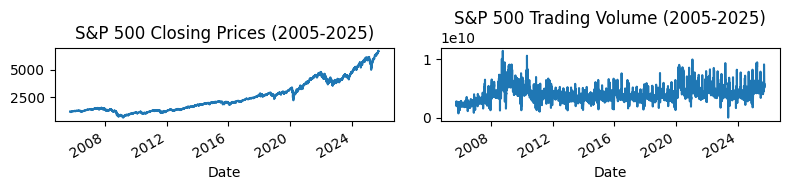

In [3]:
plt.figure(figsize=(8, 2))
plt.subplot(1, 2, 1)
raw_data.Close.plot(title="S&P 500 Closing Prices (2005-2025)")
plt.subplot(1, 2, 2)
raw_data.Volume.plot(title="S&P 500 Trading Volume (2005-2025)")
plt.tight_layout()

Under a standard geometric Brownian motion model, log-returns are normally distributed; therefore, we will consider henceforth the effect of the solar activity on the daily closing prices log-returns. 

In [4]:
data = raw_data.copy()
data["LogReturn"] = (data["Close"] / data["Close"].shift(1)).apply(lambda x: np.log(x))
# We drop the first row as it will have NaN log-return
data = data.iloc[1:, :]

# We also include both the Month and Year columns for merging purposes (see below)
data["Year"] = data.index.year
data["Month"] = data.index.month
data["Day"] = data.index.day
assert not data["LogReturn"].isna().any()

data = data[["LogReturn", "Day", "Year", "Month"]]

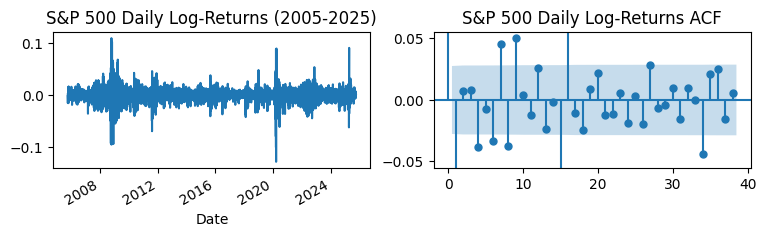

In [5]:
plt.figure(figsize=(9, 2))
ax1 = plt.subplot(1, 2, 1)
data.LogReturn.plot(title="S&P 500 Daily Log-Returns (2005-2025)", ax=ax1)
ax2 = plt.subplot(1, 2, 2)

# This is the expected autocorrelation from a white noise process
ci = 1.96 / np.sqrt(len(data))

# We plot the ACF for the log-returns
plot_acf(
    data.LogReturn,
    ax=ax2,
    title="S&P 500 Daily Log-Returns ACF",
    alpha=0.05,
    missing="raise",
)

# To clearly see the confidence intervals, we limit the y-axis
ax2.set_ylim(-2 * ci, 2 * ci)

plt.show()

This plot suggests that there is no strong temporal correlation between the S&P 500's log returns (which is a known general fact about financial time series).   

In fact, financial data has been widely studied, and stylized facts regarding their behavior are well known, see, e.g., (McNeil et al., 2005, Chapters 3-4). 
Nonetheless, a comprehensive analysis with sophisticated volatility models (e.g., GARCH) is beyond the scope of this notebook. 
We will focus on a simple OLS-based regression for assessing the relationship between sunspot frequency and the S&P500 returns. 

Towards this objective, we will first fetch the needed information on our chosen exogeneous variable from [SILSO](https://www.sidc.be/SILSO/datafiles). 

In [6]:
filename = "sunspots.csv"
if not os.path.exists(filename):
    !curl -L https://www.sidc.be/SILSO/INFO/snmtotcsv.php -o $filename

In [7]:
# Column info available at https://www.sidc.be/SILSO/infosnmtot.
sunspots = pd.read_csv(
    "sunspots.csv",
    names=[
        "Year",
        "Month",
        "DateFrac",
        "MonthlyMean",
        "MonthlyStdDev",
        "Observations",
        "IsDefinitive",
    ],
    delimiter=";",
)

# We will only need the data after 2005-12
sunspots = sunspots[
    (sunspots["Year"] > START_DATE.year) | ((sunspots["Year"] == START_DATE.year) & (sunspots["Month"] >= START_DATE.month))
]
# We create a date column for merging purposes
sunspots["Date"] = pd.to_datetime(
    sunspots["Year"].astype(str) + "-" + sunspots["Month"].astype(str)
)

In [8]:
# Verify whether some months are not covered
def check_missing_months(sunspots):
    dates = pd.to_datetime(dict(year=sunspots.Year, month=sunspots.Month, day=1))

    full = pd.date_range(dates.min(), dates.max(), freq="MS")

    missing = full.difference(dates)
    return missing


missing_months = check_missing_months(sunspots)
assert len(missing_months) == 0, f"Missing months: {missing_months}"
# Check for missing values
assert not sunspots.MonthlyMean.isna().any()

sunspots.head()

,Year,Month,DateFrac,MonthlyMean,MonthlyStdDev,Observations,IsDefinitive,Date
3080,2005,9,2005.707,37.2,4.5,691,1,2005-09-01
3081,2005,10,2005.790,13.2,3.4,534,1,2005-10-01
3082,2005,11,2005.874,27.5,4.1,499,1,2005-11-01
3083,2005,12,2005.958,59.3,3.9,419,1,2005-12-01
3084,2006,1,2006.042,20.9,3.4,511,1,2006-01-01


We then merge the data sets based on the yearly and monthly data. 
As our `sunspots` data set contains averages from the entire month, we avoid data snooping by only using data from the previous month at each day.

In [10]:
sunspots["NextMonth"] = sunspots["Month"] + 1
sunspots["NextMonth"] = sunspots["NextMonth"].replace(13, 1)

sunspots["NextYear"] = (sunspots["Month"] == 12).astype(int) + sunspots["Year"]

# We drop the last row as it will have NaN in NextMonth
sunspots = sunspots.iloc[:-1, :]

sp500_sunspots = data.merge(
    sunspots[["NextYear", "NextMonth", "MonthlyMean"]],
    left_on=["Year", "Month"],
    right_on=["NextYear", "NextMonth"],
    how="left",
    suffixes=("", "_Sunspots"),
)

# We drop the NextMonth column (which was only used for merging)
sp500_sunspots = sp500_sunspots.drop(columns=["NextMonth"])

In [13]:
assert not sp500_sunspots["MonthlyMean"].isna().any()
sp500_sunspots.head()

,LogReturn,Day,Year,Month,NextYear,MonthlyMean
0,-0.001719,3,2005,10,2005,37.2
1,-0.010020,4,2005,10,2005,37.2
2,-0.014999,5,2005,10,2005,37.2
3,-0.004104,6,2005,10,2005,37.2
4,0.003694,7,2005,10,2005,37.2


For exploration, we plot both time series. 

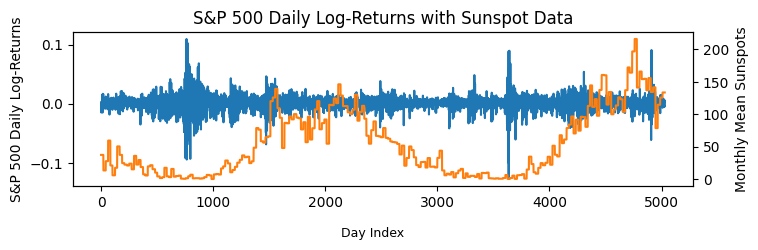

In [14]:
fig = plt.figure(figsize=(8, 2))
ax1 = sp500_sunspots.LogReturn.plot(title="S&P 500 Daily Log-Returns with Sunspot Data")
ax2 = sp500_sunspots.MonthlyMean.plot(
    secondary_y=True,
    label="Monthly Mean Sunspots",
)

ax1.set_ylabel("S&P 500 Daily Log-Returns")
ax2.set_ylabel("Monthly Mean Sunspots")
fig.supxlabel("Day Index", y=-0.16, fontsize=9)

plt.show()

We are now able to assess whether the average number of monthly sunspots significantly influences the daily log-returns for the S&P00. 

## Time Series Modelling

We provide a simple, albeit recognizably competitive, model for our time series. 
Specifically, let $\mathbf{x} = \{x_{t}\}_{t=1}^{T}$ and $\mathbf{y} = \{y_{t}\}_{t=1}^{T}$ be the SILSO-measured sunspot frequency and the S&P 500 time series, respectively.

We will start, however, by measuring the (cross-) correlation between $\mathbf{x}$ and $\mathbf{y}$. 
We also plot both $\mathbf{x}$ and $\mathbf{y}$ in a scatter plot to search for any obvious tendencies (or lack thereof). 

Text(0.5, 1.0, 'S&P 500 Daily Log-Returns vs Monthly Mean Sunspots')

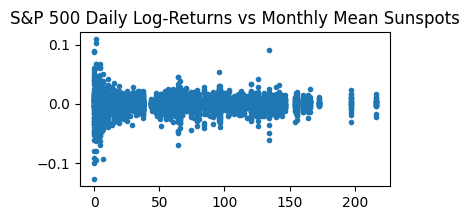

In [30]:
raw_x = sp500_sunspots["MonthlyMean"]
raw_y = sp500_sunspots["LogReturn"]

plt.figure(figsize=(4, 2))
plt.plot(raw_x, raw_y, marker=".", linestyle="none")
plt.title("S&P 500 Daily Log-Returns vs Monthly Mean Sunspots")

There is no clear sign that the sunspot frequency has any effect on the S&P 500 index, indeed, the conditional distribution $\mathbb{P}[Y_{t} | X_{t}]$ looks symmetric to the naked eye.
To validate this, we can simply test whether $\beta = 0$ in the following model. 

$$
    y_{t} \sim \mathcal{N}(\beta x_{t}, \sigma^2),
$$

with $\mathcal{N}$ as the Gaussian distribution and $\beta$ as an unknown coefficient. 

In [31]:
ols = sm.OLS(raw_y, raw_x).fit()
ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:              LogReturn   R-squared (uncentered):                   0.001
Model:                            OLS   Adj. R-squared (uncentered):              0.001
Method:                 Least Squares   F-statistic:                              4.036
Date:                Mon, 22 Dec 2025   Prob (F-statistic):                      0.0446
Time:                        11:51:16   Log-Likelihood:                          14986.
No. Observations:                5029   AIC:                                 -2.997e+04
Df Residuals:                    5028   BIC:                                 -2.996e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
MonthlyMean  4.757e-06   2.37e-06      2.009      0.045    1.15e-07     9.4e-06
==============================================================================
Omnibus:                     1170.595   Durbin-Watson:                   2.242
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            34867.058
Skew:                          -0.454   Prob(JB):                         0.00
Kurtosis:                      15.867   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Two properties stand out from this summary. 

1. The sunspot frequency alone does not provide a sufficient explanation for the variance of the S&P 500 (which is obvious and expected).

2. Although there is enough evidence (according to a $t$-test) to reject the null hypothesis that $\beta = 0$, the coefficient is practically significant. 

## Regression models

We will also consider a simple regression model, defined by 

$$
    y_{t} \sim \mathcal{N}(\beta_{1} x_{t} + \beta_{2} y_{t - 1} + \beta_{3}, \sigma^2), 
$$

in which $\beta_{1}$, $\beta_{2}$ are to-be-estimated coefficients; $\sigma^2$ is fixed but unknown. As $x_{t}$ represents the monthly average number of sunspots at the $t - 1$ month, we can safely assume that such a measurement will be available at the $t$-th stage. 
This is a simple autoregressive (AR) model with exogeneous inputs (ARX). 

In [44]:
def ols_one_step_ahead_lagged(raw_x, raw_y):
        
    y = raw_y[1:]
    X = pd.DataFrame({
        "Sunspots": raw_x[1:],
        "LaggedLogReturn": raw_y[:-1].values,
    })

    # Adding a constant is equivalent to estimating $\beta_{3}$ (the intercept)
    X = sm.add_constant(X)

    model = sm.OLS(y, X).fit()
    return model 

model = ols_one_step_ahead_lagged(raw_x, raw_y)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       LogReturn_Causal   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     14.98
Date:                Mon, 22 Dec 2025   Prob (F-statistic):           3.25e-07
Time:                        12:19:33   Log-Likelihood:                 15617.
No. Observations:                5028   AIC:                        -3.123e+04
Df Residuals:                    5025   BIC:                        -3.121e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0002      0.000      0.943      0.346      -0.000       0.001
Sunspots         2.868e-06    3.1e-06      0.927      0.354    -3.2e-06    8.94e-06
LaggedLogReturn    -0.0760      0.014     -5.405      0.000      -0.104      -0.048
==============================================================================
Omnibus:                      535.366   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2029.510
Skew:                          -0.490   Prob(JB):                         0.00
Kurtosis:                       5.954   Cond. No.                     6.74e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.74e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

We again highlight two notable properties from the above results.

1. Conditionally on the lagged log-return, the monthly average sunspot frequency does not significantly influence the current log-returns.

2. Our data does not sufficiently explain the variability of the observed log returns ($R^{2} \approx 10^{-2}$).

## Dealing with non-Gaussianity

Obviously, financial data is massively non-Gaussian due to their fat tails, and the above models can only provide educated (albeit arguably reasonable) guesses. To mitigate this issue, we winsorize the data. 

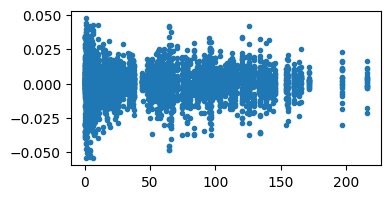

In [56]:
# We winsorize the data to mitigate the lack of Gaussianity.
# We also use a causal approach, i.e., we only use past data to compute the bounds.
lower_bound = sp500_sunspots['LogReturn'].expanding().quantile(0.01)
upper_bound = sp500_sunspots['LogReturn'].expanding().quantile(0.99)

# Clip the values using the bounds calculated from past data
sp500_sunspots['LogReturn_Causal'] = sp500_sunspots['LogReturn'].clip(lower=lower_bound, upper=upper_bound)

raw_x = sp500_sunspots["MonthlyMean"]
raw_y = sp500_sunspots["LogReturn_Causal"]

plt.figure(figsize=(4, 2))
plt.plot(raw_x, raw_y, marker=".", linestyle="none")

In [57]:
model = ols_one_step_ahead_lagged(raw_x, raw_y)
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       LogReturn_Causal   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     14.98
Date:                Mon, 22 Dec 2025   Prob (F-statistic):           3.25e-07
Time:                        12:30:44   Log-Likelihood:                 15617.
No. Observations:                5028   AIC:                        -3.123e+04
Df Residuals:                    5025   BIC:                        -3.121e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0002      0.000      0.943      0.346      -0.000       0.001
Sunspots         2.868e-06    3.1e-06      0.927      0.354    -3.2e-06    8.94e-06
LaggedLogReturn    -0.0760      0.014     -5.405      0.000      -0.104      -0.048
==============================================================================
Omnibus:                      535.366   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2029.510
Skew:                          -0.490   Prob(JB):                         0.00
Kurtosis:                       5.954   Cond. No.                     6.74e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.74e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Importantly, our conclusions remain the same when outliers are clipped; sunspot frequency has no significant influence on log-returns.

## Conclusions

We found no significant and exploitable statistical correlation between the monthly average sunspot frequency and the log-returns from the S&P 500. 
Although we have restricted our analysis to simple models---with constant volality---and a straightforward grahpical analysis, it remains unclear whether more sophisticated approaches would provide convincing evidence in favor of the influence of the astronomical factors on the market.

From an investment perspective, we believe that the monthly sunspot frequency _cannot_ not be reliably used for informed decision-making.
We leave a comprehensive investigation of such factors, however, to future work.  